In [9]:
from pathlib import Path
import os
import sys

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src" / "utils.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.utils import load_csv, data_path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
movies = load_csv('data/movies.csv')
links = load_csv('data/links.csv')  # if we wanted to refer to other websites with ratings for movies there
ratings = load_csv('data/ratings.csv')
tags = load_csv('data/tags.csv')

In [11]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [4]:
ratings["userId"].nunique()

610

In [5]:
tags['tag_timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')
tags = tags.drop('timestamp', axis=1)
tags_grouped = tags.groupby(['userId', 'movieId'])['tag'].apply(list).reset_index()

ratings['rating_timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings = ratings.drop('timestamp', axis=1)

df_rt = ratings.merge(tags, on=['userId', 'movieId'], how='left')
df = df_rt.merge(movies, on='movieId', how='left')

In [6]:
cols = [
    'userId', 'movieId', 'title', 'genres', 'rating', 'rating_timestamp', 'tag', 'tag_timestamp'
]
df = df[cols]

In [7]:
# Step 1: Split the genres into lists
df['genres_list'] = df['genres'].str.split('|')

# Step 2: Get dummy variables for each genre
genres_dummies = df['genres_list'].explode().str.get_dummies().groupby(level=0).max().astype(bool)

# Step 3: Concatenate with original dataframe
df_final = pd.concat([df.drop(columns=['genres', 'genres_list']), genres_dummies], axis=1)

In [8]:
df_final.columns

Index(['userId', 'movieId', 'title', 'rating', 'rating_timestamp', 'tag',
       'tag_timestamp', '(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='str')

In [ ]:
df_final.to_csv(data_path("joined_df.csv"))

## EDA

/tmp/ipykernel_849699/3015513200.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


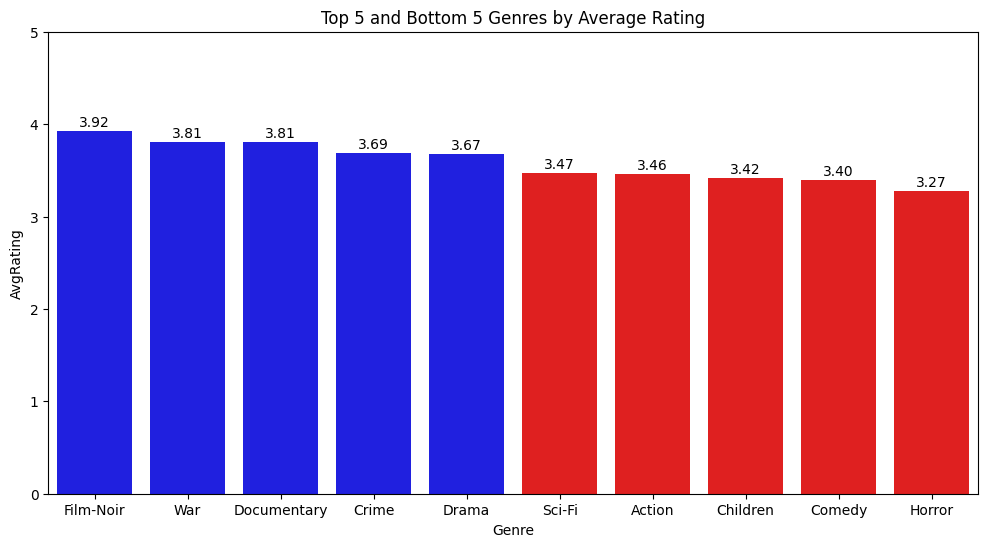

Film-Noir             3.920455
War                   3.810485
Documentary           3.806593
Crime                 3.688081
Drama                 3.674577
Mystery               3.648368
Animation             3.643208
IMAX                  3.628347
Western               3.605799
Musical               3.570024
(no genres listed)    3.530612
Thriller              3.518859
Adventure             3.516471
Romance               3.512123
Fantasy               3.497081
Sci-Fi                3.471624
Action                3.460531
Children              3.417717
Comedy                3.399324
Horror                3.274028
dtype: float64


In [9]:
# Step 1: Identify genre columns
genre_cols = ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Step 2: Compute average rating per genre
genre_avg_rating = {}
for genre in genre_cols:
    # Only consider rows where genre is True
    genre_avg_rating[genre] = df_final.loc[df_final[genre], 'rating'].mean()

genre_avg_rating = pd.Series(genre_avg_rating).sort_values(ascending=False)

# Step 3: Top 5 and bottom 5
top5 = genre_avg_rating.head(5)
bottom5 = genre_avg_rating.tail(5)

# Step 4: Combine for plotting
plot_df = pd.concat([top5, bottom5]).reset_index()
plot_df.columns = ['Genre', 'AvgRating']

# Step 5: Assign colors
plot_df['Color'] = ['blue']*5 + ['red']*5

# Step 6: Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_df, 
    x='Genre', 
    y='AvgRating', 
    palette=plot_df['Color'].tolist()  # <-- convert Series to list
)
plt.title('Top 5 and Bottom 5 Genres by Average Rating')
plt.ylim(0, 5)

# Annotate average rating on bars
for i, row in plot_df.iterrows():
    plt.text(i, row['AvgRating'] + 0.05, f"{row['AvgRating']:.2f}", ha='center')

plt.show()

print(genre_avg_rating)

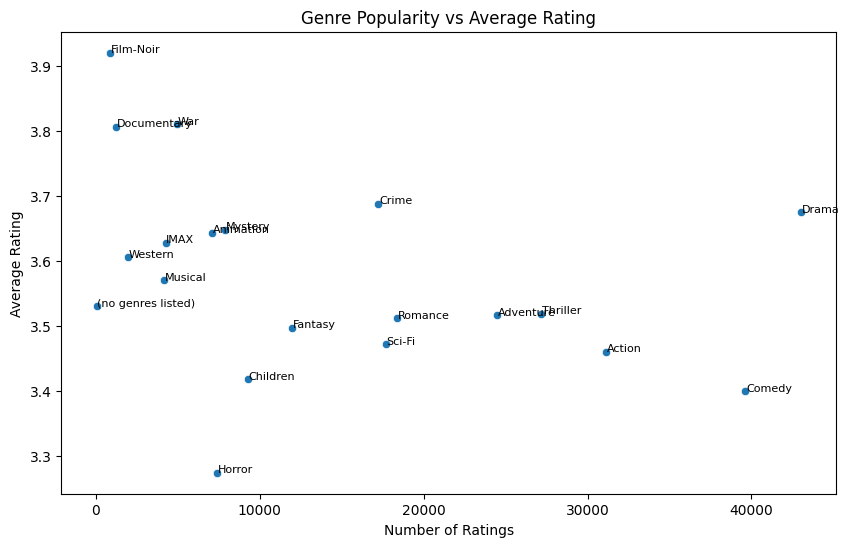

In [10]:
# Count how many ratings each genre has
genre_counts = {}
for genre in genre_cols:
    genre_counts[genre] = df_final[genre].sum()

genre_counts = pd.Series(genre_counts)

# Combine with average rating
genre_summary = pd.DataFrame({
    'AvgRating': genre_avg_rating,
    'Count': genre_counts
})

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=genre_summary,
    x='Count',
    y='AvgRating'
)

# Label a few points
for i in genre_summary.index:
    plt.text(
        genre_summary.loc[i, 'Count'] + 50,
        genre_summary.loc[i, 'AvgRating'],
        i,
        fontsize=8
    )

plt.title("Genre Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

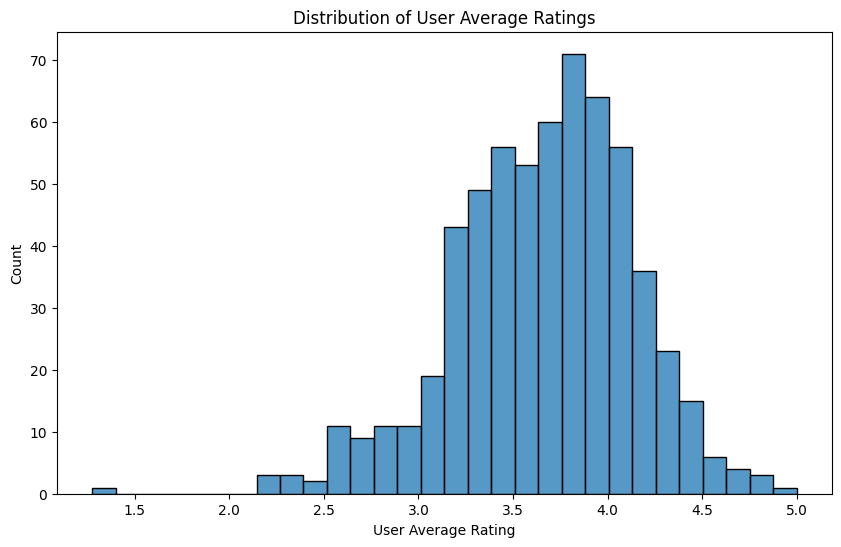

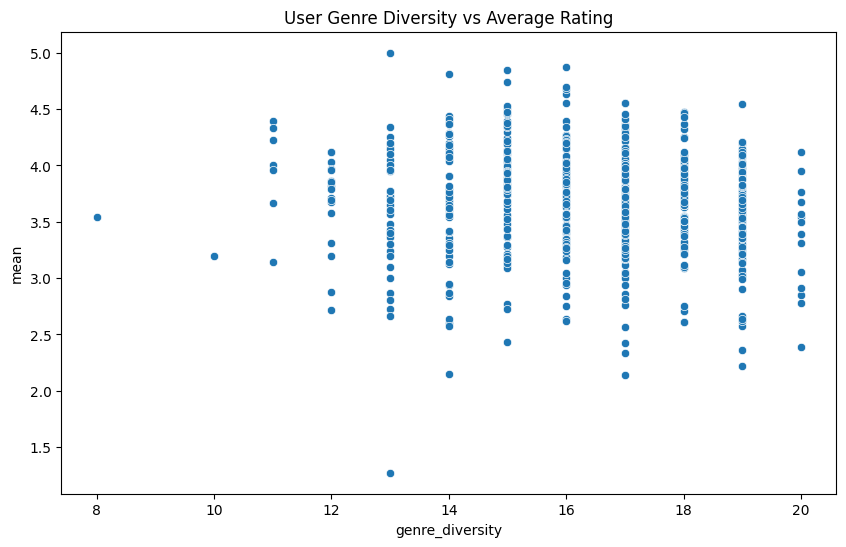

In [11]:
# Count how many genres each user has watched
user_stats = df_final.groupby('userId')['rating'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(10,6))
sns.histplot(user_stats['mean'], bins=30)
plt.title("Distribution of User Average Ratings")
plt.xlabel("User Average Rating")
plt.show()

user_stats['type'] = pd.cut(
    user_stats['mean'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Harsh', 'Neutral', 'Generous']
)

user_genre_diversity = {}

for user, group in df_final.groupby('userId'):
    genres_watched = group[genre_cols].sum() > 0
    user_genre_diversity[user] = genres_watched.sum()

user_div = pd.Series(user_genre_diversity, name='genre_diversity')

user_summary = user_stats.join(user_div)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=user_summary,
    x='genre_diversity',
    y='mean'
)

plt.title("User Genre Diversity vs Average Rating")
plt.show()

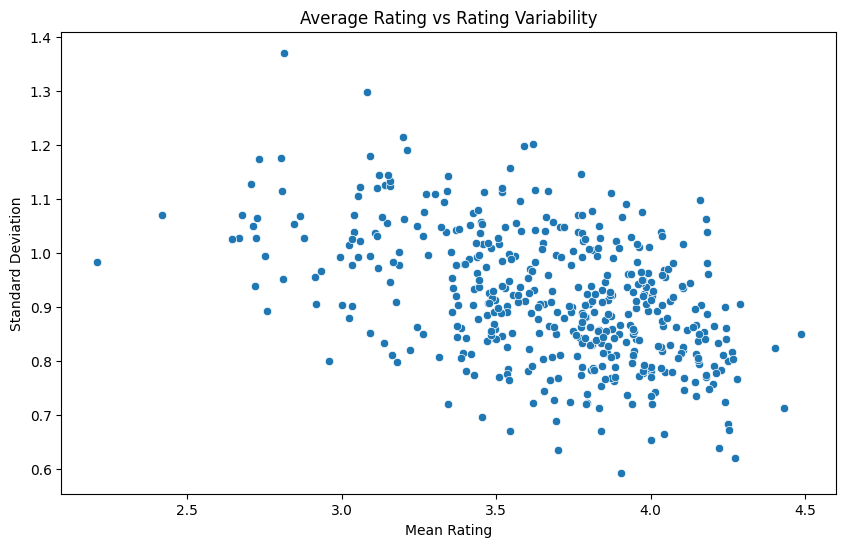

In [12]:

movie_var = df_final.groupby('movieId')['rating'].agg(['mean', 'std', 'count'])

# Filter for movies with enough ratings
movie_var = movie_var[movie_var['count'] > 50]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movie_var,
    x='mean',
    y='std'
)

plt.title("Average Rating vs Rating Variability")
plt.xlabel("Mean Rating")
plt.ylabel("Standard Deviation")
plt.show()

As shown below, the more popular a movie tends to be, the better ratings it has. This shows that there is potentially a correlation between how high a rating is and how popular a movie is. The higher the rating, the more popular the movie. 

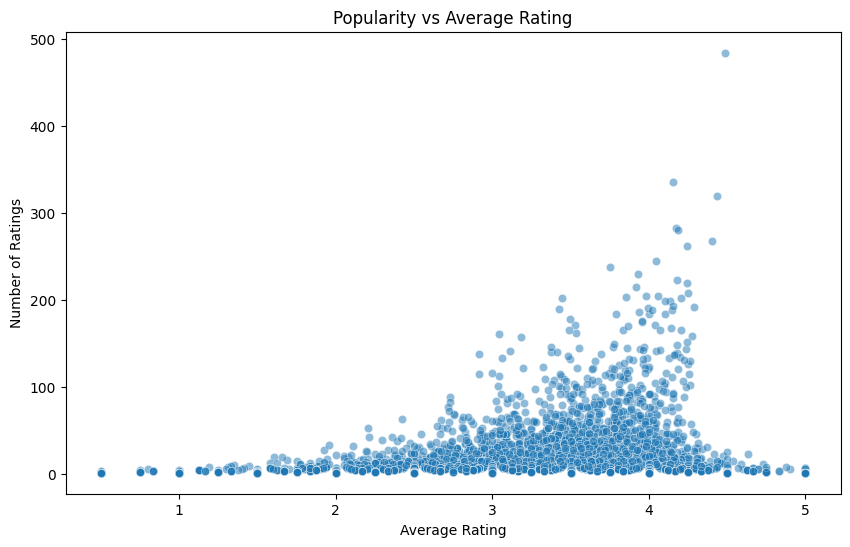

In [13]:
movie_counts = df_final.groupby('movieId')['rating'].count().rename('num_ratings')
movie_avg = df_final.groupby('movieId')['rating'].mean().rename('avg_rating')

movie_summary = pd.concat([movie_counts, movie_avg], axis=1)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movie_summary,
    x='avg_rating',
    y='num_ratings',
    alpha=0.5
)

plt.title("Popularity vs Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Number of Ratings")
plt.show()

The chart below shows how the different genres relate to one another. As shown below, most often Children's movies are animated and have the strongest correlation to one another. 

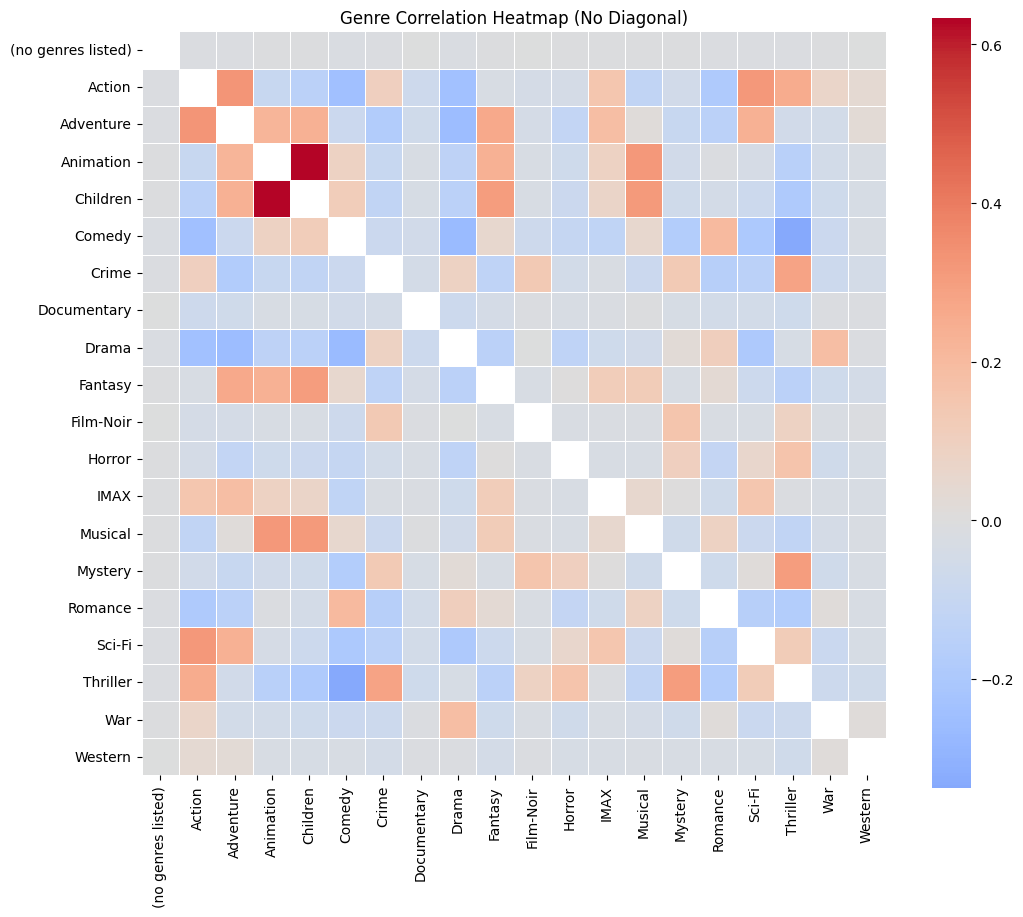

In [14]:
# Correlation matrix
import numpy as np

genre_corr = df_final[genre_cols].corr()

mask = np.eye(len(genre_corr), dtype=bool)

plt.figure(figsize=(12,10))
sns.heatmap(
    genre_corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Genre Correlation Heatmap (No Diagonal)")
plt.show()

The chart below I find the most interesting. Often I've noticed how different film students tend to appreciate the "film noir" genre a bit more because of it's class and nostalgia. However, horror is most commonly rated negatively.

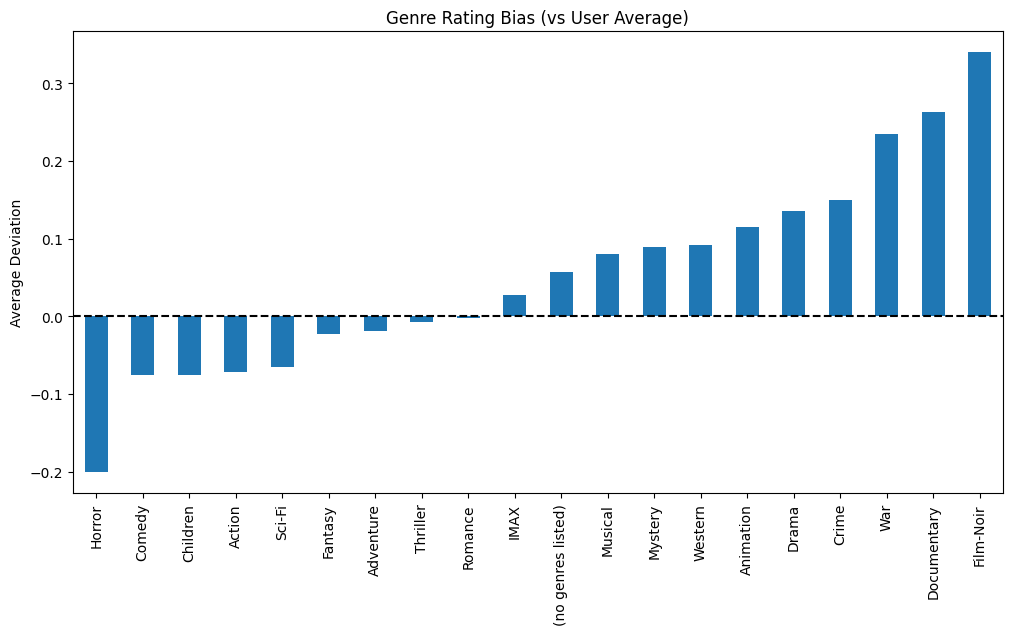

In [15]:
# Compute user average rating
user_avg = df_final.groupby('userId')['rating'].mean().rename('user_avg')

df_bias = df_final.merge(user_avg, on='userId')
df_bias['rating_diff'] = df_bias['rating'] - df_bias['user_avg']

# Compute average bias per genre
genre_bias = {}
for genre in genre_cols:
    genre_bias[genre] = df_bias.loc[df_bias[genre], 'rating_diff'].mean()

genre_bias = pd.Series(genre_bias).sort_values()

# Plot
plt.figure(figsize=(12,6))
genre_bias.plot(kind='bar')
plt.axhline(0, color='black', linestyle='--')
plt.title("Genre Rating Bias (vs User Average)")
plt.ylabel("Average Deviation")
plt.show()